#  Práctica: Probabilidad Básica

Aplicamos los conceptos de `teoria.qmd` en tres bloques:

1. Simulación de Monte Carlo (dados y cartas)
2. Teorema de Bayes paso a paso (test médico)
3. Un filtro de spam simplificado basado en Naive Bayes

Todo apoyado en las funciones de `stats_toolkit.probability`.

In [1]:
import sys
sys.path.append("../../src")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from stats_toolkit import probability as prob

sns.set_theme(style="whitegrid")

## 1. Monte Carlo: probabilidad de la suma de dos dados

La probabilidad teórica de que la suma de dos dados sea 7 es $6/36 \approx 0.1667$ (hay 6 combinaciones favorables sobre 36 posibles). Vamos a estimarla simulando miles de lanzamientos y comprobar que la Ley de los Grandes Números nos acerca al valor teórico.

In [2]:
sums_ = prob.roll_dice(n_dice=2, n_trials=100_000, seed=42)

p_siete_empirica = prob.empirical_probability(sums_, lambda s: s == 7)
p_siete_teorica = 6 / 36

print(f"P(suma = 7) empírica: {p_siete_empirica:.4f}")
print(f"P(suma = 7) teórica:  {p_siete_teorica:.4f}")

P(suma = 7) empírica: 0.1683
P(suma = 7) teórica:  0.1667


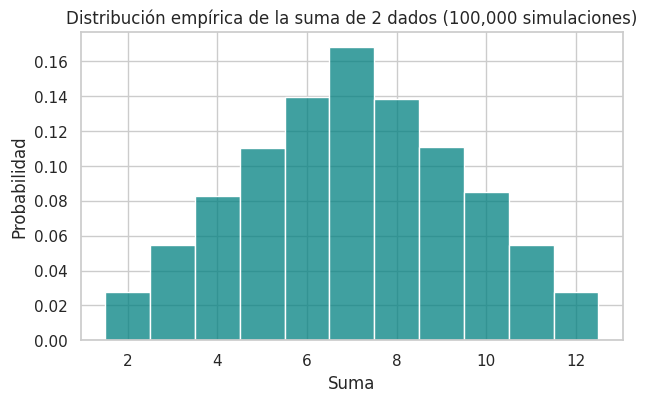

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(sums_, bins=range(2, 14), discrete=True, stat="probability", ax=ax, color="teal")
ax.set_title("Distribución empírica de la suma de 2 dados (100,000 simulaciones)")
ax.set_xlabel("Suma")
ax.set_ylabel("Probabilidad")
plt.show()

### Convergencia de Monte Carlo

Un aspecto clave de la simulación es que la estimación mejora (converge) a medida que aumentamos el número de ensayos. Vamos a visualizarlo.

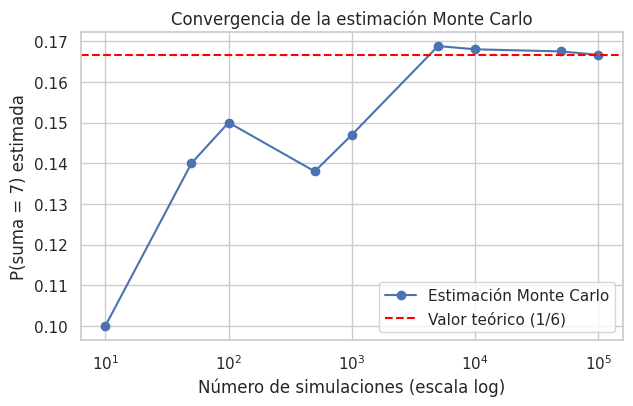

In [4]:
tamanos = np.array([10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000, 100_000])
estimaciones = []

rng_sums = prob.roll_dice(n_dice=2, n_trials=100_000, seed=7)
for n in tamanos:
    estimaciones.append(prob.empirical_probability(rng_sums[:n], lambda s: s == 7))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tamanos, estimaciones, marker="o", label="Estimación Monte Carlo")
ax.axhline(p_siete_teorica, color="red", linestyle="--", label="Valor teórico (1/6)")
ax.set_xscale("log")
ax.set_xlabel("Número de simulaciones (escala log)")
ax.set_ylabel("P(suma = 7) estimada")
ax.set_title("Convergencia de la estimación Monte Carlo")
ax.legend()
plt.show()

## 2. Probabilidad condicional con cartas

Sin reemplazo: ¿cuál es la probabilidad de sacar dos ases seguidos de una baraja de 52 cartas?

Teóricamente: $P(A_1) \times P(A_2 \mid A_1) = \frac{4}{52} \times \frac{3}{51}$

In [5]:
def simular_dos_ases(rng):
    baraja = list(range(52))  # 0-3 representan los 4 ases
    rng.shuffle(baraja)
    primera, segunda = baraja[0], baraja[1]
    return primera < 4 and segunda < 4

rng = np.random.default_rng(42)
n_trials = 200_000
exitos = sum(simular_dos_ases(rng) for _ in range(n_trials))
p_empirica = exitos / n_trials
p_teorica = (4/52) * (3/51)

print(f"P(dos ases seguidos) empírica: {p_empirica:.5f}")
print(f"P(dos ases seguidos) teórica:  {p_teorica:.5f}")

P(dos ases seguidos) empírica: 0.00442
P(dos ases seguidos) teórica:  0.00452


## 3. Teorema de Bayes: el caso del test médico

Retomamos el ejemplo de la teoría: una enfermedad con prevalencia del 1%, un test con 95% de sensibilidad y 5% de falsos positivos. Calculamos $P(\text{Enfermo} \mid \text{Test}+)$ usando `stats_toolkit.probability`.

In [6]:
prior_enfermo = 0.01
sensibilidad = 0.95          # P(+ | Enfermo)
falsos_positivos = 0.05      # P(+ | Sano)

evidencia = prob.total_probability(
    likelihoods=[sensibilidad, falsos_positivos],
    priors=[prior_enfermo, 1 - prior_enfermo],
)

posterior = prob.bayes_theorem(prior_enfermo, sensibilidad, evidencia)

print(f"P(Test+) [evidencia]:        {evidencia:.4f}")
print(f"P(Enfermo | Test+):          {posterior:.4f}")

P(Test+) [evidencia]:        0.0590
P(Enfermo | Test+):          0.1610


### Sensibilidad del resultado al prior

¿Qué pasaría si la enfermedad fuera más común (prior más alto)? Visualicemos cómo cambia la probabilidad posterior en función de la prevalencia.

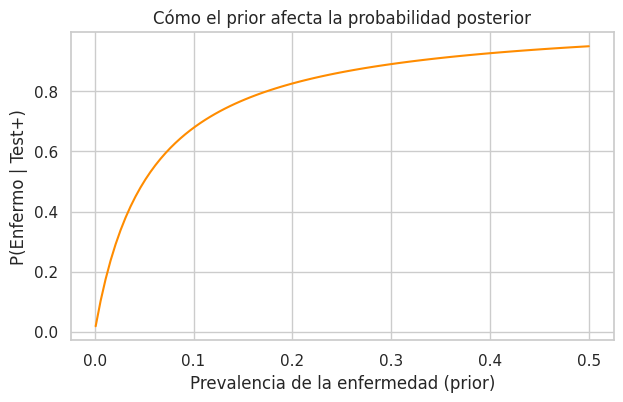

In [7]:
priors = np.linspace(0.001, 0.5, 100)
posteriores = []

for p in priors:
    ev = prob.total_probability([sensibilidad, falsos_positivos], [p, 1 - p])
    posteriores.append(prob.bayes_theorem(p, sensibilidad, ev))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(priors, posteriores, color="darkorange")
ax.set_xlabel("Prevalencia de la enfermedad (prior)")
ax.set_ylabel("P(Enfermo | Test+)")
ax.set_title("Cómo el prior afecta la probabilidad posterior")
plt.show()

**Conclusión clave:** con priors bajos (enfermedades raras), incluso un test muy sensible produce muchos falsos positivos en términos relativos. Este es el mismo principio detrás de por qué los filtros de spam necesitan calibrarse con cuidado — si el spam es poco frecuente en tu bandeja, un clasificador ingenuo puede marcar erróneamente muchos correos legítimos.

## 4. Filtro de spam simplificado con Naive Bayes

Ahora aplicamos el mismo razonamiento bayesiano a texto. Entrenamos un `SimpleTextNaiveBayes` con un mini-corpus de mensajes etiquetados como `spam` o `ham` (no-spam), y lo usamos para clasificar mensajes nuevos.

In [8]:
mensajes_entrenamiento = [
    "gana dinero rapido ahora",
    "oferta exclusiva solo hoy",
    "premio gratis reclama ya",
    "gana un viaje gratis ahora",
    "reunion de trabajo manana",
    "informe de ventas adjunto",
    "agenda la reunion del proyecto",
    "revisar el informe antes del viernes",
]
etiquetas_entrenamiento = ["spam", "spam", "spam", "spam", "ham", "ham", "ham", "ham"]

modelo_spam = prob.SimpleTextNaiveBayes(alpha=1.0).fit(mensajes_entrenamiento, etiquetas_entrenamiento)

mensajes_prueba = [
    "gana un premio gratis hoy",
    "revisar informe de la reunion",
    "oferta especial solo para ti",
    "agenda la reunion de ventas",
]

for m in mensajes_prueba:
    proba = modelo_spam.predict_proba(m)
    pred = modelo_spam.predict(m)
    print(f"'{m}'")
    print(f"  -> P(spam)={proba['spam']:.3f}  P(ham)={proba['ham']:.3f}  =>  Predicción: {pred}\n")

'gana un premio gratis hoy'
  -> P(spam)=0.998  P(ham)=0.002  =>  Predicción: spam

'revisar informe de la reunion'
  -> P(spam)=0.002  P(ham)=0.998  =>  Predicción: ham

'oferta especial solo para ti'
  -> P(spam)=0.912  P(ham)=0.088  =>  Predicción: spam

'agenda la reunion de ventas'
  -> P(spam)=0.004  P(ham)=0.996  =>  Predicción: ham



### Visualizando las probabilidades de clasificación

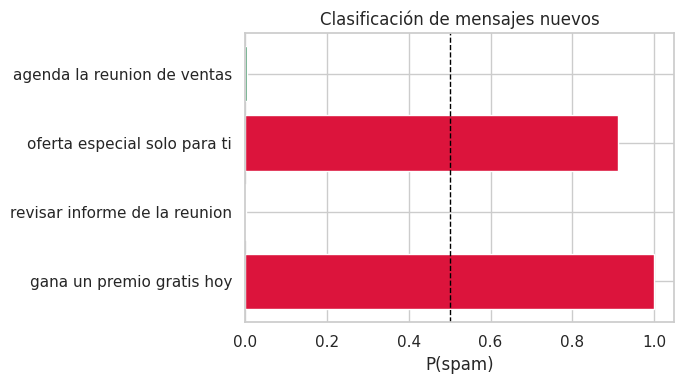

In [9]:
probas_spam = [modelo_spam.predict_proba(m)["spam"] for m in mensajes_prueba]

fig, ax = plt.subplots(figsize=(7, 4))
colores = ["crimson" if p > 0.5 else "seagreen" for p in probas_spam]
ax.barh(mensajes_prueba, probas_spam, color=colores)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("P(spam)")
ax.set_title("Clasificación de mensajes nuevos")
plt.tight_layout()
plt.show()

## 5. Ejercicio propuesto

> **Tu turno:**
> 1. Agrega 4 mensajes nuevos (2 spam, 2 ham) al corpus de entrenamiento y reentrena el modelo. ¿Cambian las predicciones de `mensajes_prueba`?
> 2. Calcula manualmente, usando `prob.bayes_theorem`, la probabilidad posterior de que un correo sea spam si sabes que P(spam)=0.3 (prior), y que la palabra "gratis" aparece en el 80% de los spams pero solo en el 5% de los correos legítimos. ¿Cómo se compara con lo que predice el modelo?

```python
# Escribe tu solución aquí
```